
# Step 06 — EGFP dynamics, Müller glia sub-states, rods and cones

**Purpose.** Answer research questions 3, 4 and 5.

## The positivity rule, stated once

A cell is **EGFP-positive** if its raw count for the transgene feature is
≥ `cfg.EGFP_POSITIVE_MIN_COUNTS` (default 1).

Justification: 3′ UMI data are sparse and a single-copy transgene yields low
counts, so any higher cut is arbitrary without evidence from the observed
distribution — which is why that distribution is plotted first. The continuous
log-normalised value is reported alongside the binary call throughout, so no
conclusion rests on the threshold alone.

## The interpretive guard

`careg:EGFP` reports **regenerative activation**, not cell identity. Bise et al.
found EGFP mostly in activated Müller glia and largely *absent* from the
proliferating progenitor clusters at 7 dpMNU — so EGFP⁺ and `pcna`⁺ are not
expected to coincide everywhere. An EGFP⁺ cell in a non-MG cluster is a finding to
examine (ambient RNA? doublet? genuine non-MG activity?), not a reason to relabel
the cluster.

In [1]:
import sys
from pathlib import Path

# Make the repository root importable regardless of where Jupyter was launched.
REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "scripts").exists():
    REPO_ROOT = REPO_ROOT.parent
assert (REPO_ROOT / "scripts").exists(), (
    f"Cannot locate the repository root from {Path.cwd()}. "
    "Launch JupyterLab from the repository root."
)
sys.path.insert(0, str(REPO_ROOT))

from scripts import config as cfg
from scripts import io_utils, qc, preprocessing, clustering, annotation, egfp_analysis, plotting

cfg.ensure_directories()
plotting.set_style()
SEED = io_utils.set_seeds()
print(f"Repository root: {REPO_ROOT}")
print(f"Random seed: {SEED}")

Repository root: D:\retina\project1_zebrafish_retina
Random seed: 0


In [2]:
import pandas as pd
adata = io_utils.load_checkpoint("annotated")

Loaded 'annotated': 15893 cells x 2000 genes



## 1. Resolve the EGFP feature and call positivity

In [3]:
adata, egfp_name = egfp_analysis.add_egfp_columns(adata)

if egfp_name is None:
    print(
        "EGFP is not in this count matrix. Research question 3 and Figure 4 cannot "
        "be answered from these data. Report that explicitly in the Results section "
        "and do not substitute another gene."
    )

EGFP feature found in var_names as: 'EGFP'
EGFP feature 'EGFP': 481/15893 cells positive (3.03%) at >= 1 raw count(s). Max counts in one cell: 256.


In [4]:
if egfp_name is not None:
    dist = egfp_analysis.egfp_count_distribution(adata)
    display(dist.head(15))
    print(
        "\nIf almost all positive cells carry exactly 1 count, >0 is the only "
        "defensible threshold. If there is a clear gap in the distribution, a higher "
        "cut can be justified -- but then change cfg.EGFP_POSITIVE_MIN_COUNTS, record "
        "it in cfg.PARAM_OVERRIDES, and state the evidence in Methods."
    )

,egfp_counts,n_cells,pct_of_all_cells
0,0,15412,96.974
1,1,310,1.951
2,2,76,0.478
3,3,34,0.214
4,4,10,0.063
5,5,13,0.082
6,6,8,0.050
7,7,4,0.025
8,8,3,0.019
9,9,1,0.006



If almost all positive cells carry exactly 1 count, >0 is the only defensible threshold. If there is a clear gap in the distribution, a higher cut can be justified -- but then change cfg.EGFP_POSITIVE_MIN_COUNTS, record it in cfg.PARAM_OVERRIDES, and state the evidence in Methods.



## 2. EGFP across the time course (research question 3)

In [5]:
if egfp_name is not None:
    egfp_by_cond = egfp_analysis.egfp_by_condition(adata)
    display(egfp_by_cond[["condition", "sample", "percent_positive",
                          "mean_percent_positive", "min_percent_positive",
                          "max_percent_positive"]])

    egfp_table = egfp_analysis.egfp_summary(adata)
    io_utils.save_table(egfp_table, "egfp_summary.csv")

,condition,sample,percent_positive,mean_percent_positive,min_percent_positive,max_percent_positive
0,ctrl,ctrl1,0.55,0.56,0.55,0.56
1,ctrl,ctrl2,0.56,0.56,0.55,0.56
2,3dp,3dp1,3.63,5.40,3.63,7.16
3,3dp,3dp2,7.16,5.40,3.63,7.16
4,7dp,7dp1,3.43,2.45,1.46,3.43
5,7dp,7dp2,1.46,2.45,1.46,3.43
6,10dp,10dp1,2.16,2.80,2.16,3.43
7,10dp,10dp2,3.43,2.80,2.16,3.43


Wrote tables\egfp_summary.csv  (102 rows)


In [6]:
if egfp_name is not None:
    enrichment = egfp_analysis.egfp_enrichment_by_cluster(adata)
    io_utils.save_table(enrichment, "egfp_enrichment_by_cell_type.csv")
    display(enrichment)

Wrote tables\egfp_enrichment_by_cell_type.csv  (13 rows)


,cell_type,n_cells,n_egfp_positive,percent_positive,enrichment_vs_dataset,share_of_all_egfp_cells
0,Muller glia,1807,205,11.34,3.75,42.62
9,Pericytes,51,3,5.88,1.94,0.62
5,Retinal ganglion cells,97,5,5.15,1.70,1.04
4,Amacrine cells,1274,48,3.77,1.24,9.98
2,Cones,2614,83,3.18,1.05,17.26
11,Unresolved,1077,27,2.51,0.83,5.61
7,Oligodendrocytes,129,3,2.33,0.77,0.62
3,Bipolar cells,1758,33,1.88,0.62,6.86
6,Microglia,661,12,1.82,0.60,2.49
12,Rods (low quality),1062,12,1.13,0.37,2.49



## Figure 4 — EGFP dynamics

Saved figure_04_egfp_dynamics -> figures\figure_04_egfp_mg/ (png, pdf)
Saved figure_04_egfp_vs_proliferation -> figures\figure_04_egfp_mg/ (png, pdf)


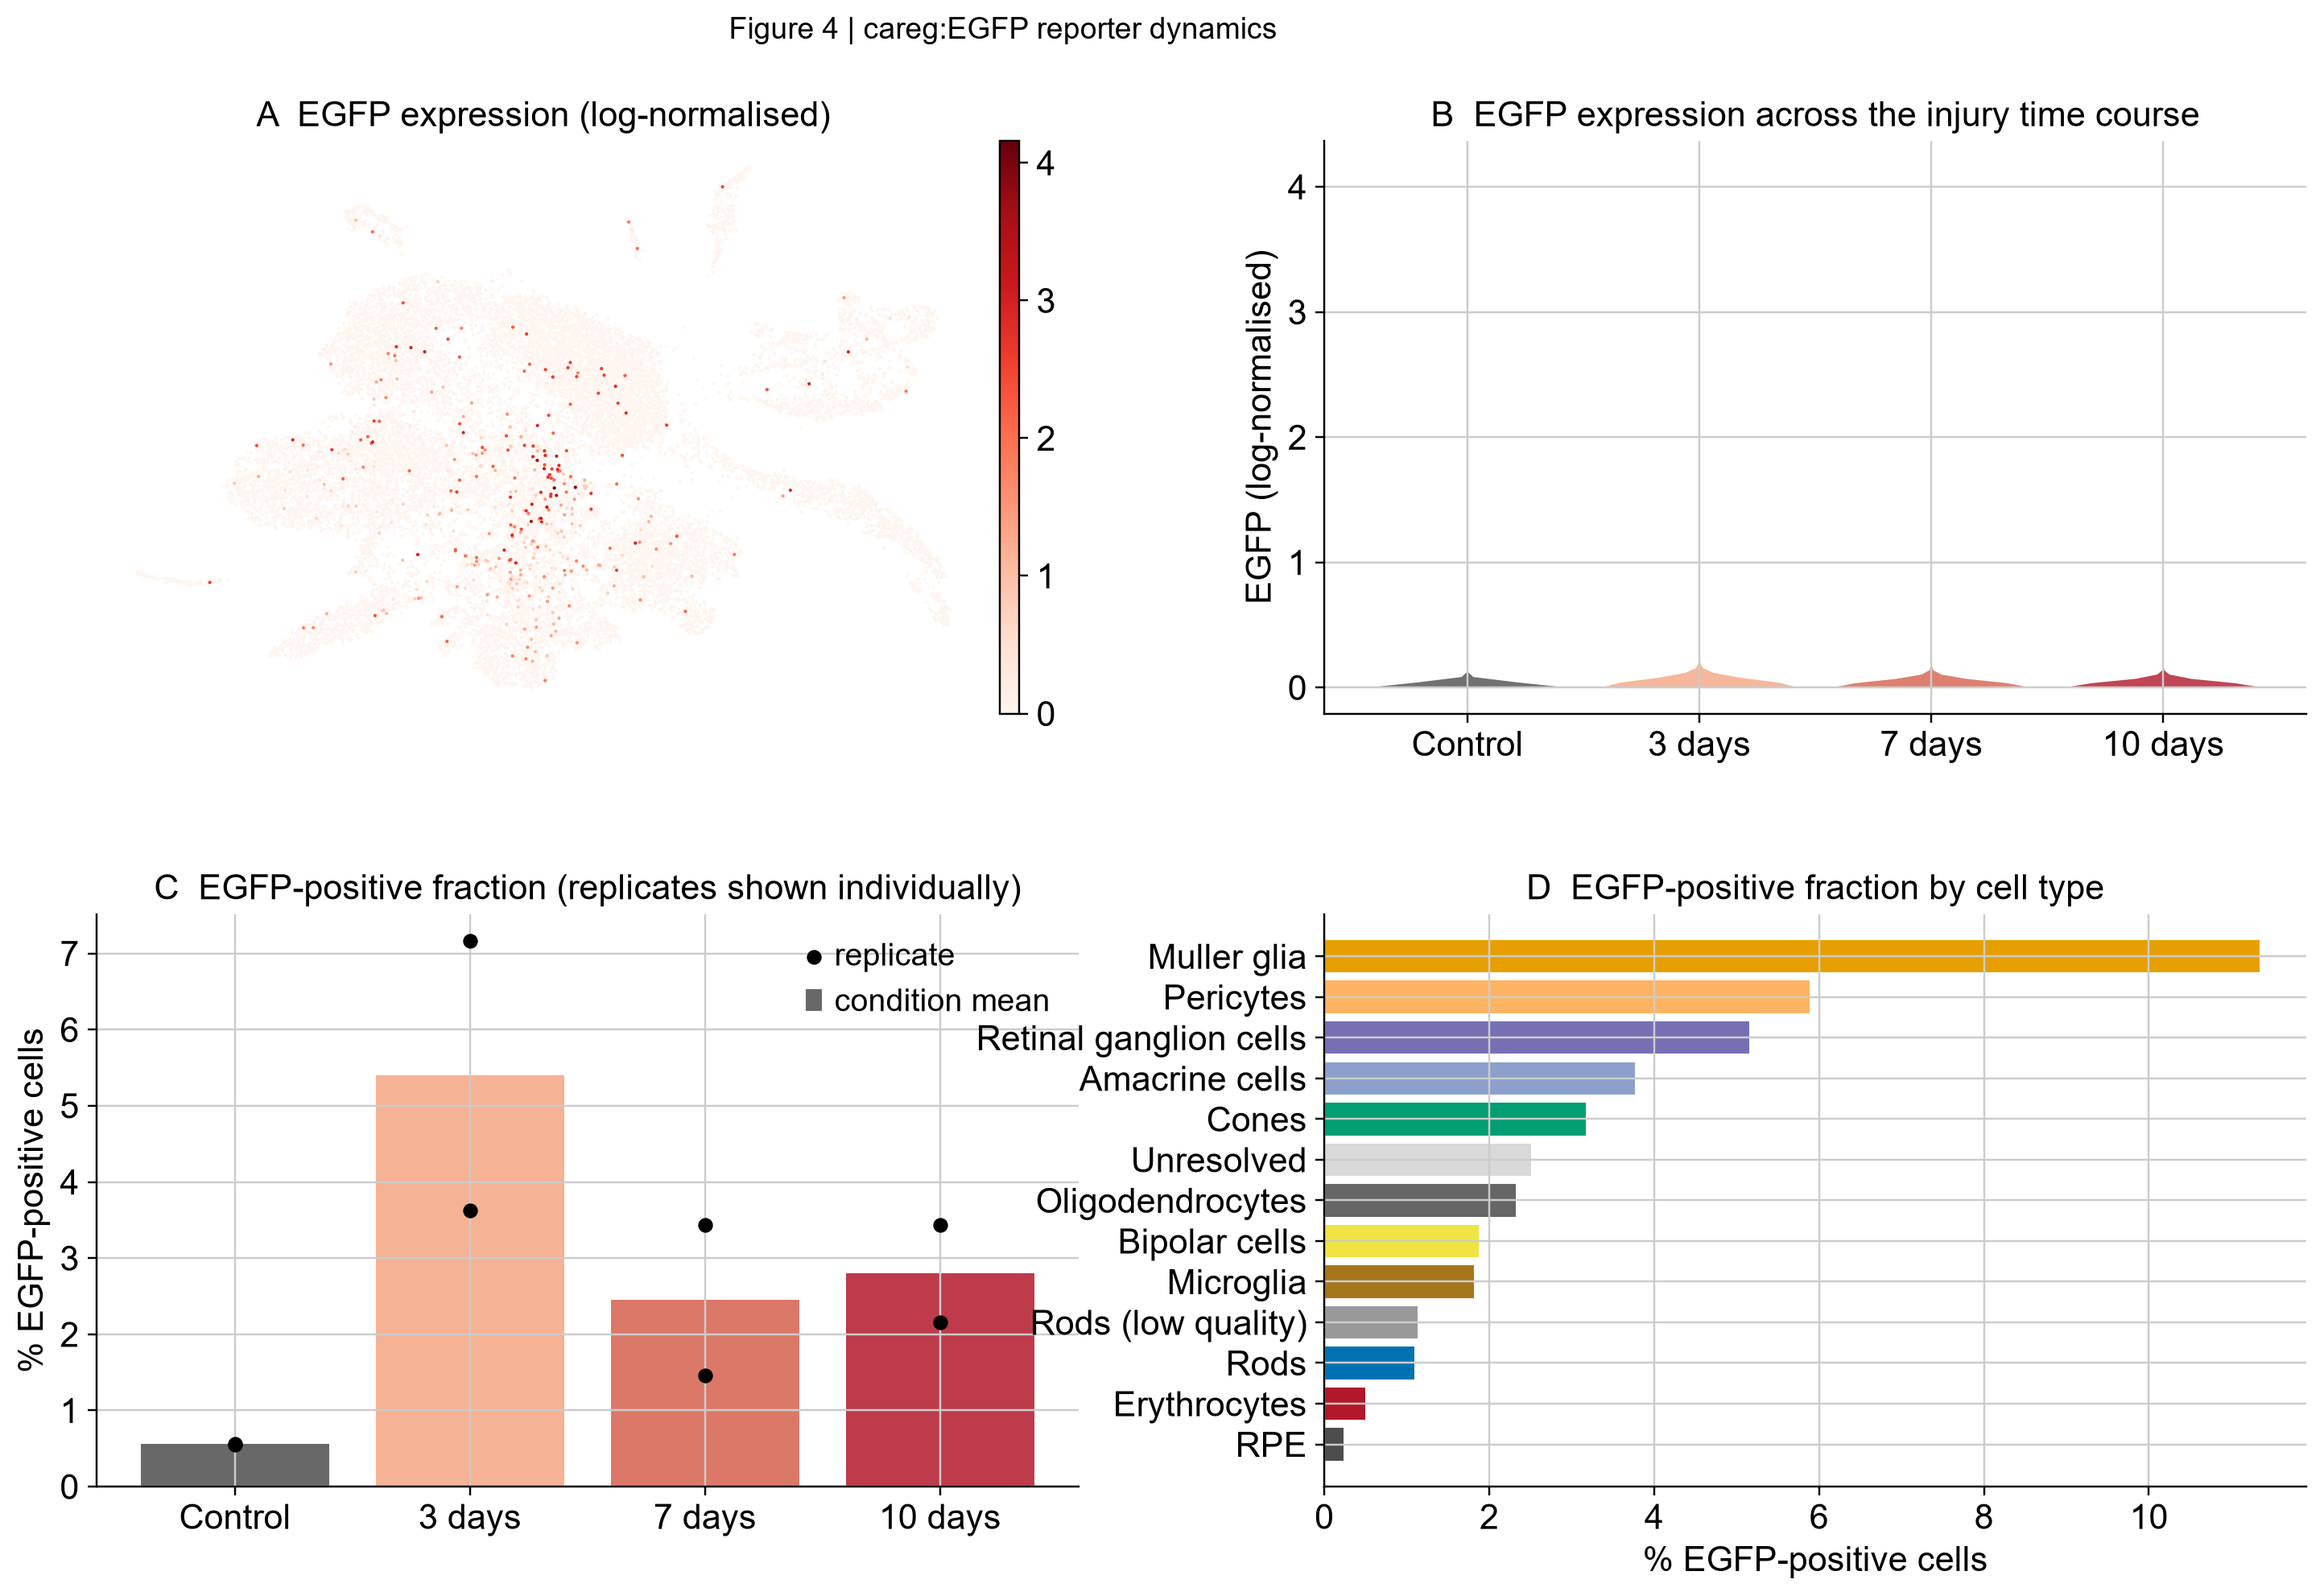

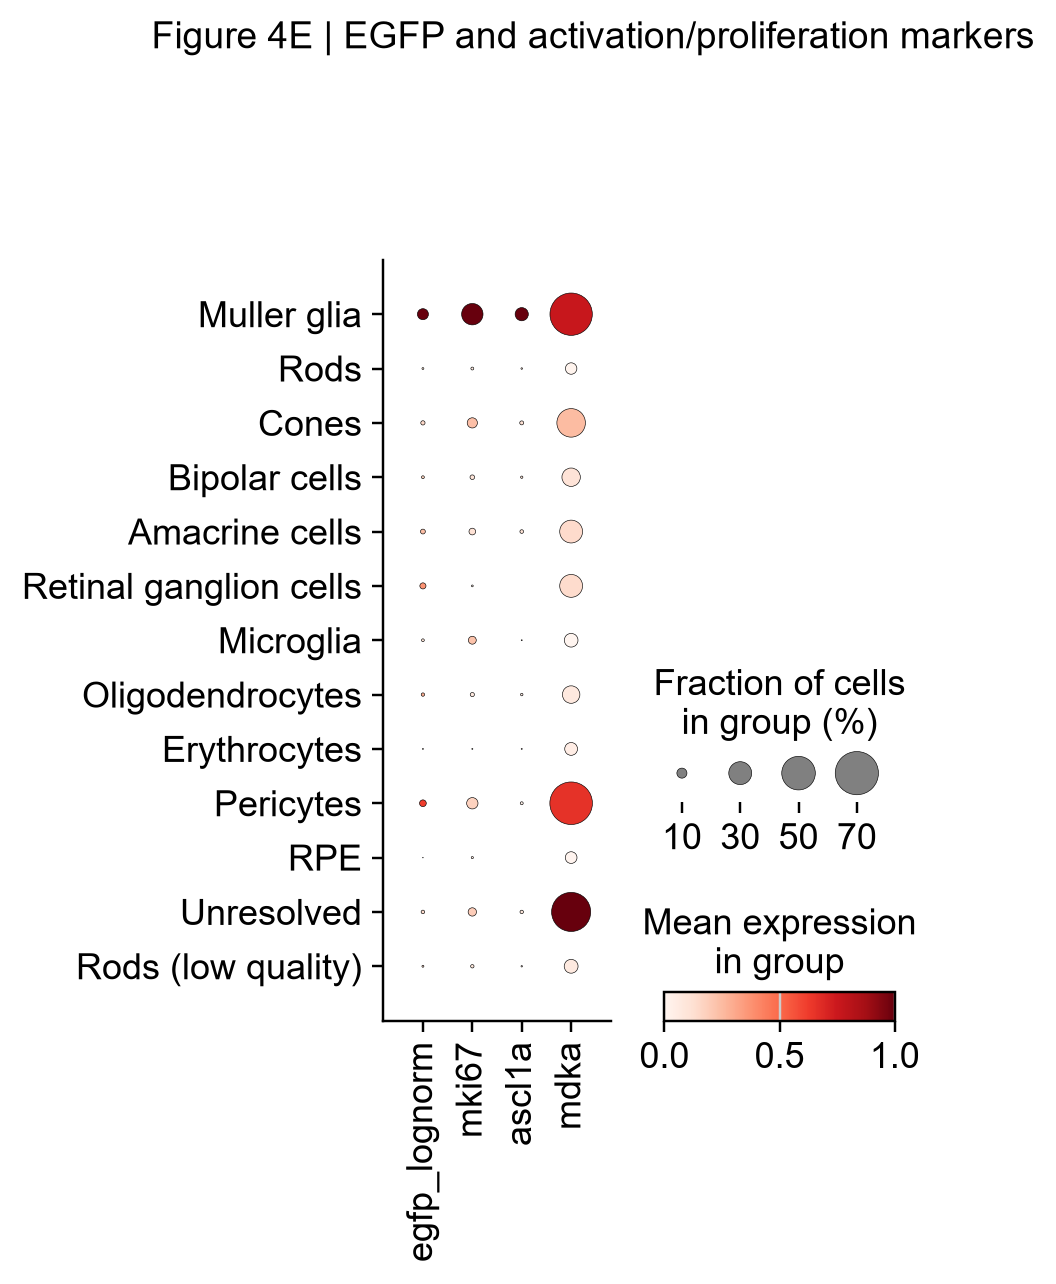

In [7]:
if egfp_name is not None:
    fig = plotting.figure_04_egfp(adata, egfp_by_cond)
    fig = plotting.figure_04_activation_markers(adata)


### Interpretation — comparison points, not targets

Bise et al. report, from their scRNA-seq: EGFP⁺ cells at 0.54% of control cells,
5.40% at 3 dpMNU, 2.64% at 7 dpMNU and 2.66% at 10 dpMNU, with ~10% of Müller glia
EGFP⁺ and MG far above every other cluster.

Three separate things to state, kept apart:

- **Observed result** — the percentages you actually measured, per replicate.
- **Comparison with the paper** — same direction? similar magnitude? peak at the
  same timepoint?
- **If they differ**, work through the candidate causes rather than asserting one:
  different normalisation (log vs SCTransform), no integration here, different
  clustering resolution, different QC thresholds, or a genuinely different
  transgene-detection rate. Some of these are checkable; say which.

Note that the guide's phrasing ("does expression subside by day 10") anticipates a
decline. The paper's own numbers show EGFP still at ~2.6% at day 10 — reduced from
the day-3 peak but not back to control. Report what you measure.


## 3. Müller glia deep dive (research question 4)

Identity first: the subset is defined by the annotation, never by EGFP.

In [8]:
mg = egfp_analysis.subset_muller_glia(adata)
mg = egfp_analysis.recluster_subset(mg, resolution=0.3)

Muller glia subset: 1807 cells from ['Muller glia']
Sub-analysis rebuilt from .raw: 22813 genes available (vs 2000 in the HVG-subset object).


C:\Users\Lenovo\AppData\Roaming\uv\python\cpython-3.11-windows-x86_64-none\Lib\functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
D:\retina\project1_zebrafish_retina\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Subset re-clustered at resolution 0.3: 8 subclusters, 1807 cells.


In [9]:
mg_evidence = egfp_analysis.mg_state_evidence(mg)
io_utils.save_table(mg_evidence.reset_index(), "mg_substate_evidence.csv")
display(mg_evidence)
print("\n" + egfp_analysis.MG_STATE_GUIDANCE)

Wrote tables\mg_substate_evidence.csv  (8 rows)


,n_cells,pct_egfp_positive,pct_ctrl,pct_3dp,pct_7dp,pct_10dp,rlbp1a,glula,glulb,slc1a3b,gfap,apoeb,pcna,mki67,ascl1a,her4.1,stat3,mdka
subcluster,,,,,,,,,,,,,,,,,,
0,264,18.56,22.0,15.2,24.6,38.3,2.921,4.076,1.323,0.014,1.523,3.486,0.292,0.230,0.121,0.069,0.363,2.985
1,81,3.70,17.3,8.6,32.1,42.0,0.649,1.889,0.314,0.000,0.350,0.795,0.119,0.025,0.020,0.038,0.063,0.995
2,260,27.69,1.9,35.0,20.4,42.7,1.148,1.727,0.668,0.001,0.857,1.734,1.249,1.640,0.356,0.090,0.285,1.821
3,656,7.77,4.6,34.1,16.9,44.4,1.793,2.668,0.596,0.000,0.965,2.004,0.327,0.320,0.174,0.012,0.083,1.823
4,130,3.85,0.0,3.8,30.8,65.4,0.608,1.171,0.186,0.000,0.300,0.605,0.152,0.230,0.037,0.000,0.144,0.361
5,241,0.83,24.9,23.7,25.3,26.1,1.278,2.022,0.413,0.000,0.387,1.591,0.322,0.489,0.128,0.061,0.055,1.763
6,156,10.90,25.0,26.9,22.4,25.6,0.851,1.348,0.472,0.000,0.607,2.674,0.931,0.622,0.465,0.076,0.126,1.994
7,19,31.58,26.3,26.3,21.1,26.3,0.143,1.426,0.065,0.000,0.008,0.361,1.311,1.403,0.480,0.280,0.030,3.064



Reading the MG evidence table: a resting state should be high on identity markers (rlbp1a, glula/glulb, slc1a3b) and low on pcna/mki67/ascl1a; an activated state keeps identity markers while gaining ascl1a/her4.1/EGFP; a progenitor-like state loses identity markers and gains pcna/mki67. If no subcluster shows the third pattern, report two states, not three. Note also that the paper found EGFP mostly in activated MG and largely ABSENT from the proliferating progenitor clusters, so EGFP+ and pcna+ need not coincide.


Saved figure_04_mg_substates -> figures\figure_04_egfp_mg/ (png, pdf)


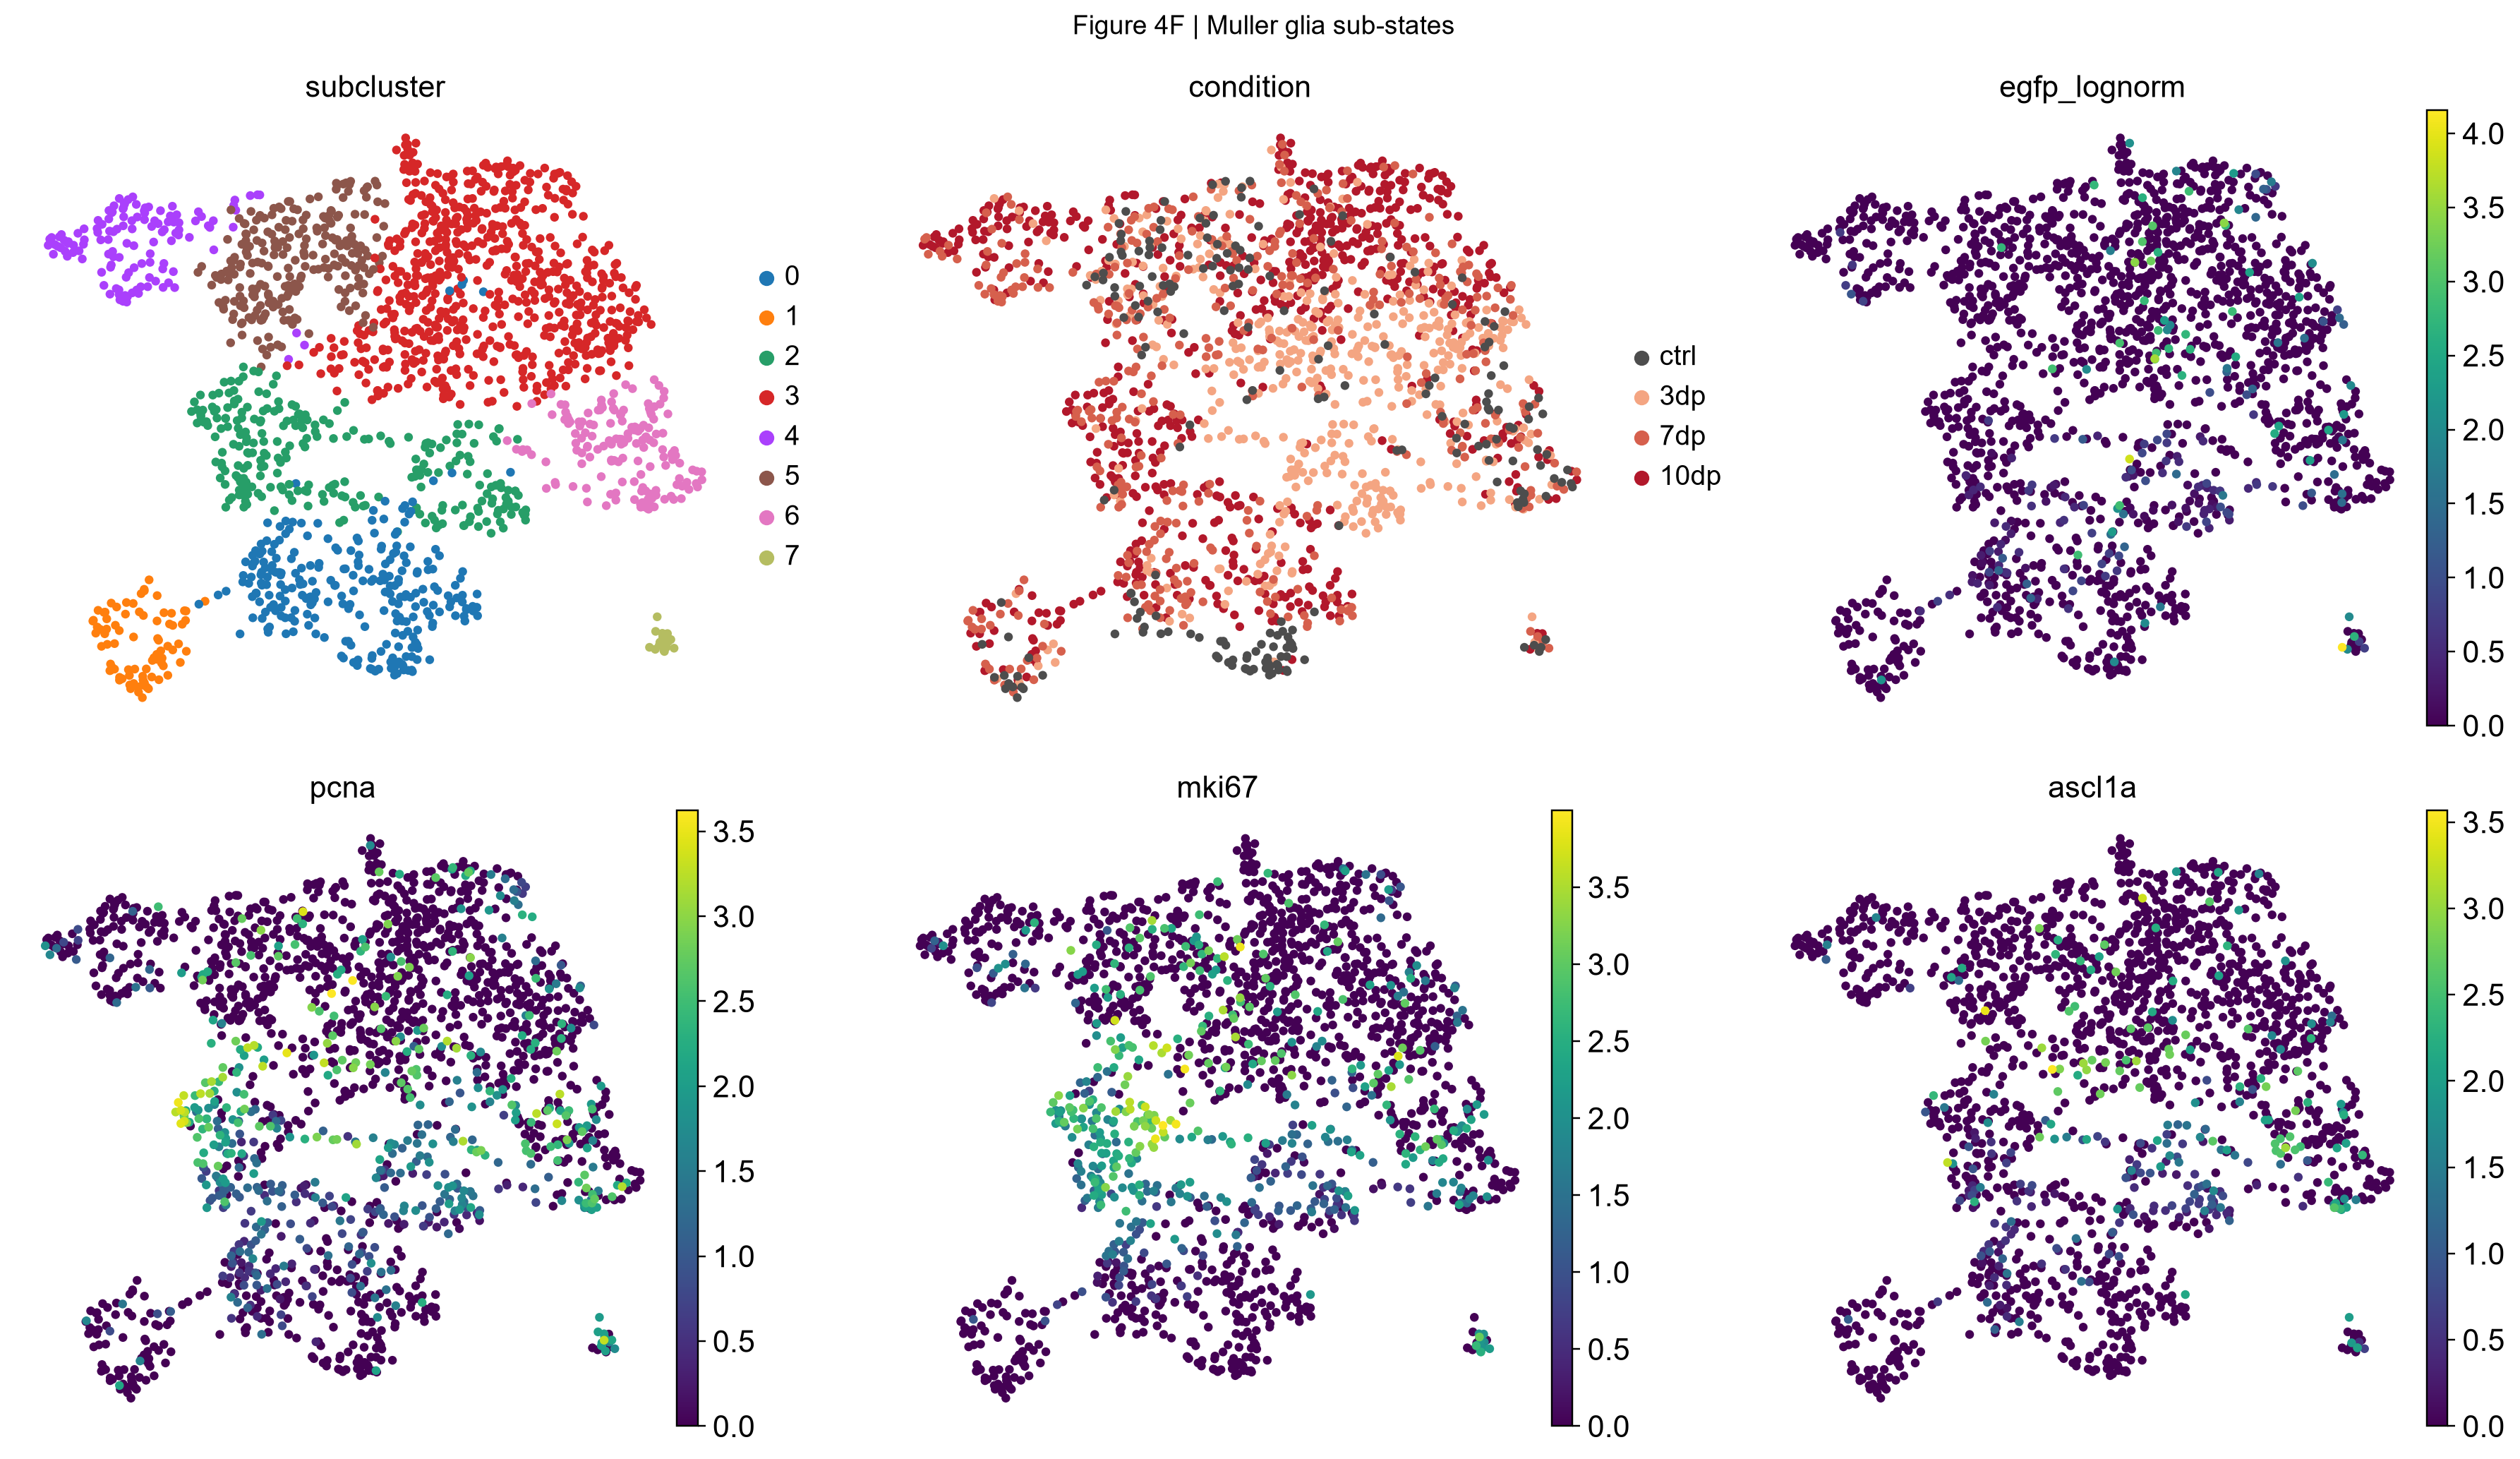

In [10]:
fig = plotting.figure_04_mg_umap(mg)


### Interpretation — resist manufacturing three states

The question asks whether resting, activated and progenitor-like MG can be
distinguished. The defensible answers, in order of preference:

1. **Three states resolved** — one subcluster high on identity markers and low on
   activation; one keeping identity while gaining `ascl1a`/`her4.1`/EGFP; one
   losing identity and gaining `pcna`/`mki67`, enriched in injured samples.
2. **Two states resolved** — very common at this cell number. Report two.
3. **No sub-structure** — subclusters differ by depth or ribosomal content rather
   than by biology. That is a legitimate negative result: say the data do not
   resolve MG sub-states at this depth.

Progenitors may also not sit inside the MG cluster at all: if they have
transcriptionally moved away from MG identity, global clustering will have placed
them elsewhere. Check whether a `pcna`-high cluster exists outside this subset
before concluding that progenitors are absent.

In [11]:
# EGFP+ vs EGFP- Muller glia -- the analogue of the paper's 42-gene signature.
if egfp_name is not None:
    mg_types = [ct for ct in adata.obs["cell_type"].cat.categories
                if "muller" in str(ct).lower()]
    de_frames = [egfp_analysis.egfp_de_within_group(adata, ct) for ct in mg_types]
    de_frames = [d for d in de_frames if len(d)]
    if de_frames:
        mg_de = pd.concat(de_frames, ignore_index=True)
        io_utils.save_table(mg_de, "egfp_pos_vs_neg_muller_glia.csv")
        display(mg_de.head(30))

Wrote tables\egfp_pos_vs_neg_muller_glia.csv  (2000 rows)


,group,n_egfp_pos,n_egfp_neg,gene,score,logfoldchange,pval,pval_adj
0,Muller glia,205,1602,EGFP,23.343695,31.074837,1.597145e-120,3.194289e-117
1,Muller glia,205,1602,krt8,10.520834,1.597504,6.925804e-26,6.925804e-23
2,Muller glia,205,1602,qki2,10.360404,1.497918,3.753733e-25,2.502489e-22
3,Muller glia,205,1602,htra1b,10.123633,1.971674,4.339992e-24,2.169996e-21
4,Muller glia,205,1602,txn,10.031796,1.771262,1.104875e-23,4.419499e-21
5,Muller glia,205,1602,serpinb1,9.517171,1.625481,1.779582e-21,5.931939e-19
6,Muller glia,205,1602,s100a10b,9.381335,1.625307,6.514265e-21,1.861218e-18
7,Muller glia,205,1602,cd63,9.213370,1.475359,3.160414e-20,7.901035e-18
8,Muller glia,205,1602,yap1,9.190412,1.126979,3.913413e-20,8.696474e-18
9,Muller glia,205,1602,cxcl14,9.083790,1.751415,1.048584e-19,2.097168e-17



## 4. Rods (research question 5)

The paper describes two rod populations — an immature-like cluster (high `rho`,
`pde6ga`, `guca1a`, plus `meig1`, `ppdpfa`, `rom1b`) and a mature-like one (high
`rhol`, `pde6gb`, `guca1b`, phototransduction machinery). The paralog usage is
inverted between them.

We do **not** import those labels. We re-cluster the rods, look at the same genes,
and report whether the split is reproduced.

In [12]:
rods, rod_evidence = egfp_analysis.rod_heterogeneity_evidence(adata)
io_utils.save_table(rod_evidence.reset_index(), "rod_subcluster_evidence.csv")
display(rod_evidence)

Sub-analysis rebuilt from .raw: 22813 genes available (vs 2000 in the HVG-subset object).


C:\Users\Lenovo\AppData\Roaming\uv\python\cpython-3.11-windows-x86_64-none\Lib\functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


Subset re-clustered at resolution 0.3: 4 subclusters, 5376 cells.
[rod maturity panel] not in this dataset (1): ['prom1']
Wrote tables\rod_subcluster_evidence.csv  (4 rows)


,n_cells,pct_ctrl,pct_3dp,pct_7dp,pct_10dp,rho,rhol,pde6ga,pde6gb,guca1a,...,meig1,ppdpfa,rom1b,gnat1,gngt1,nr2e3,sagb,rcvrna,gnb1a,crx
subcluster,,,,,,,,,,,,,,,,,,,,,
0,418,8.4,31.3,17.7,42.6,6.353,1.122,3.815,4.698,1.673,...,0.315,3.913,2.921,4.463,4.291,0.257,3.171,0.788,4.132,1.211
1,3149,1.1,27.4,31.9,39.6,7.631,1.271,3.928,5.717,2.908,...,1.078,5.753,4.170,5.175,5.305,0.128,2.948,0.673,4.183,0.627
2,1786,13.7,36.3,21.3,28.7,6.216,1.687,4.317,4.735,1.615,...,0.253,3.659,2.810,4.472,4.210,0.315,3.502,1.739,4.241,1.332
3,23,0.0,8.7,30.4,60.9,5.618,1.509,3.804,4.055,1.805,...,0.798,3.374,2.700,3.862,3.721,1.048,2.898,1.222,3.595,2.501



### Interpretation

The decisive test is the **paralog inversion**: does one subcluster carry `rho` /
`pde6ga` / `guca1a` while another carries `rhol` / `pde6gb` / `guca1b`? That
pattern is specific and hard to produce by accident, so reproducing it is real
support for the paper's interpretation. `meig1` and `ppdpfa` restricted to the
immature-like subcluster would corroborate it.

If instead the subclusters differ mainly by total counts, gene number or
mitochondrial content, the split is technical and should be reported as such.

Note the ordering trap: an "immature" label implies a developmental trajectory
that a single snapshot cannot establish. Phrase it as *transcriptionally
immature-like*, and keep the developmental claim in the Discussion as an
interpretation of the paper's, not a result of yours.

In [13]:
# Injury response within rods: each timepoint against control.
rod_types = [ct for ct in adata.obs["cell_type"].cat.categories if "rod" in str(ct).lower()]
frames = []
for ct in rod_types:
    for cond in ["3dp", "7dp", "10dp"]:
        d = egfp_analysis.injury_response_de(adata, cell_type=ct, condition=cond)
        if len(d):
            frames.append(d.head(cfg.DE_TOP_N))
if frames:
    rod_de = pd.concat(frames, ignore_index=True)
    io_utils.save_table(rod_de, "rod_injury_response_de.csv")
    display(rod_de.groupby(["cell_type", "comparison"], observed=True).head(5))

Skipping Rods (low quality) 3dp vs ctrl: 226 vs 15 cells.
Skipping Rods (low quality) 7dp vs ctrl: 470 vs 15 cells.
Skipping Rods (low quality) 10dp vs ctrl: 351 vs 15 cells.
Wrote tables\rod_injury_response_de.csv  (150 rows)


,cell_type,comparison,n_cells_test,n_cells_reference,gene,score,logfoldchange,pval,pval_adj
0,Rods,3dp_vs_ctrl,1419,299,rbp4l,17.444880,2.244147,3.765063e-68,7.530126e-65
1,Rods,3dp_vs_ctrl,1419,299,guca1a,13.506599,2.981478,1.429749e-41,1.429749e-38
2,Rods,3dp_vs_ctrl,1419,299,mt-co2,12.290726,1.773943,1.015899e-34,6.772660e-32
3,Rods,3dp_vs_ctrl,1419,299,apoc1,8.546004,3.968153,1.274231e-17,6.371155e-15
4,Rods,3dp_vs_ctrl,1419,299,ppdpfa,7.487775,0.680788,7.005098e-14,2.335033e-11
50,Rods,7dp_vs_ctrl,995,299,guca1a,17.555437,3.989566,5.404969e-69,1.080994e-65
51,Rods,7dp_vs_ctrl,995,299,mt-co2,15.428171,2.228102,1.058273e-53,1.058273e-50
52,Rods,7dp_vs_ctrl,995,299,rbp4l,11.600469,1.440738,4.098271e-31,2.732180e-28
53,Rods,7dp_vs_ctrl,995,299,fabp7a,10.322451,3.446446,5.578112e-25,2.546845e-22
54,Rods,7dp_vs_ctrl,995,299,rho,10.309743,0.490787,6.367112e-25,2.546845e-22



## 5. Cones

In [14]:
cones, cone_evidence = egfp_analysis.cone_subtype_evidence(adata)
io_utils.save_table(cone_evidence.reset_index(), "cone_subcluster_evidence.csv")
display(cone_evidence)

Sub-analysis rebuilt from .raw: 22813 genes available (vs 2000 in the HVG-subset object).


C:\Users\Lenovo\AppData\Roaming\uv\python\cpython-3.11-windows-x86_64-none\Lib\functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


Subset re-clustered at resolution 0.3: 7 subclusters, 2614 cells.
Wrote tables\cone_subcluster_evidence.csv  (7 rows)


,n_cells,pct_ctrl,pct_3dp,pct_7dp,pct_10dp,opn1sw1,opn1sw2,opn1mw1,opn1mw2,opn1lw1,opn1lw2,arr3a,arr3b,tbx2a,cngb3.2,guca1e,gnat2,pde6c
subcluster,,,,,,,,,,,,,,,,,,
0,364,22.3,24.2,25.8,27.7,2.873,2.713,1.294,2.561,1.736,1.931,2.587,1.077,0.171,0.408,0.397,3.615,2.761
1,752,25.7,23.9,26.1,24.3,2.950,2.270,0.632,2.444,1.096,1.152,3.289,1.601,0.210,0.295,0.180,3.432,3.100
2,408,2.5,29.4,20.3,47.8,2.677,2.234,0.674,2.202,1.627,1.413,3.431,2.075,0.590,1.055,0.387,3.682,3.228
3,406,1.2,32.5,9.9,56.4,0.703,1.081,0.410,2.144,1.504,1.017,3.910,0.833,0.103,1.103,0.230,3.864,3.632
4,285,38.2,37.2,6.3,18.2,5.068,1.270,0.146,0.428,0.211,0.296,0.830,3.344,1.088,1.770,1.484,4.026,3.112
5,184,25.5,26.1,23.9,24.5,2.644,2.064,0.654,1.739,1.090,1.039,3.295,1.704,0.370,0.362,0.177,2.904,2.826
6,215,96.3,1.4,0.5,1.9,1.854,2.234,1.736,2.955,2.321,2.439,2.428,0.783,0.269,0.950,1.161,3.564,3.032


In [15]:
frames = []
cone_types = [ct for ct in adata.obs["cell_type"].cat.categories if "cone" in str(ct).lower()]
for ct in cone_types:
    for cond in ["3dp", "7dp", "10dp"]:
        d = egfp_analysis.injury_response_de(adata, cell_type=ct, condition=cond)
        if len(d):
            frames.append(d.head(cfg.DE_TOP_N))
if frames:
    cone_de = pd.concat(frames, ignore_index=True)
    io_utils.save_table(cone_de, "cone_injury_response_de.csv")
    display(cone_de.groupby(["cell_type", "comparison"], observed=True).head(5))

Wrote tables\cone_injury_response_de.csv  (150 rows)


,cell_type,comparison,n_cells_test,n_cells_reference,gene,score,logfoldchange,pval,pval_adj
0,Cones,3dp_vs_ctrl,677,652,rbp4l,12.097383,1.170019,1.090306e-33,2.180613e-30
1,Cones,3dp_vs_ctrl,677,652,guca1c,7.882254,0.711191,3.215280e-15,2.143520e-12
2,Cones,3dp_vs_ctrl,677,652,apoc1,7.367417,2.563663,1.739659e-13,8.698296e-11
3,Cones,3dp_vs_ctrl,677,652,rcvrn3,7.067750,1.010089,1.574654e-12,5.248845e-10
4,Cones,3dp_vs_ctrl,677,652,apoeb,6.940864,1.229567,3.897088e-12,1.113454e-09
50,Cones,7dp_vs_ctrl,476,652,hsp70l,9.875073,2.263202,5.339379e-23,5.339379e-20
51,Cones,7dp_vs_ctrl,476,652,rbp4l,9.753025,1.045205,1.790511e-22,1.193674e-19
52,Cones,7dp_vs_ctrl,476,652,arr3a,8.327773,1.181670,8.237710e-17,2.745903e-14
53,Cones,7dp_vs_ctrl,476,652,hsp70.3,7.926467,1.952481,2.254683e-15,6.441952e-13
54,Cones,7dp_vs_ctrl,476,652,hsp90aa1.2,7.757876,1.036887,8.636355e-15,2.159089e-12



### Interpretation — two limits to state plainly

1. **No recovery claim is available from these data.** The series ends at 10 days.
   The paper's structural restoration is at 30 dpMNU (rods, outer plexiform layer)
   and 40 dpMNU (UV cone outer segments), measured by immunofluorescence, not
   scRNA-seq. Whatever the 10-day transcriptome shows, it cannot demonstrate
   recovery.
2. **The DE tests are descriptive.** With two replicates per condition, a
   cell-level Wilcoxon test treats each cell as an independent sample and
   overstates significance — cells within a replicate are correlated. Use the
   ranking to identify candidate genes; do not present the adjusted p-values as
   population-level evidence. A pseudobulk test over the eight samples would be the
   correct design, and saying so is better than pretending the cell-level p-values
   are what they appear to be.


## 6. Biological validation report

In [16]:
checks = {
    "1. Major retinal cell types detected":
        sorted(str(c) for c in adata.obs["cell_type"].cat.categories),
    "2. Muller glia identifiable":
        bool([c for c in adata.obs["cell_type"].cat.categories if "muller" in str(c).lower()]),
    "3. EGFP concentrated in the expected population":
        (egfp_analysis.egfp_enrichment_by_cluster(adata).iloc[0].to_dict()
         if egfp_name else "EGFP absent from matrix"),
    "4. EGFP changes across the time course":
        (egfp_analysis.egfp_by_condition(adata)
         .drop_duplicates("condition")[["condition", "mean_percent_positive"]]
         .to_dict("records") if egfp_name else "n/a"),
    "5. Proliferation markers present":
        [g for g in ["pcna", "mki67"] if g in adata.raw.var_names],
    "6. Rod subclusters found": int(rods.obs["subcluster"].nunique()),
    "7. Cone subclusters found": int(cones.obs["subcluster"].nunique()),
    "8. Composition shifts": "see tables/cell_type_proportions.csv (capture-bias caveat applies)",
    "9. Replicate vs condition effect": "see tables/batch_diagnostics.csv",
}
for key, value in checks.items():
    print(f"{key}\n    {value}\n")

1. Major retinal cell types detected
    ['Amacrine cells', 'Bipolar cells', 'Cones', 'Erythrocytes', 'Microglia', 'Muller glia', 'Oligodendrocytes', 'Pericytes', 'RPE', 'Retinal ganglion cells', 'Rods', 'Rods (low quality)', 'Unresolved']

2. Muller glia identifiable
    True

3. EGFP concentrated in the expected population
    {'cell_type': 'Muller glia', 'n_cells': 1807, 'n_egfp_positive': 205, 'percent_positive': 11.34, 'enrichment_vs_dataset': 3.75, 'share_of_all_egfp_cells': 42.62}

4. EGFP changes across the time course
    [{'condition': 'ctrl', 'mean_percent_positive': 0.56}, {'condition': '3dp', 'mean_percent_positive': 5.4}, {'condition': '7dp', 'mean_percent_positive': 2.45}, {'condition': '10dp', 'mean_percent_positive': 2.8}]

5. Proliferation markers present
    ['pcna', 'mki67']

6. Rod subclusters found
    4

7. Cone subclusters found
    7

8. Composition shifts
    see tables/cell_type_proportions.csv (capture-bias caveat applies)

9. Replicate vs condition effect
 

In [17]:
validation = pd.DataFrame([
    {"question": k, "answer": str(v)} for k, v in checks.items()
])
io_utils.save_table(validation, "biological_validation.csv")

mg.write_h5ad(cfg.RESULTS_DIR / "06_muller_glia.h5ad", compression="gzip")
io_utils.save_checkpoint(adata, "mg_egfp")

Wrote tables\biological_validation.csv  (9 rows)
Saved checkpoint 'mg_egfp' -> results\06_mg_egfp.h5ad (183.2 MB)


WindowsPath('D:/retina/project1_zebrafish_retina/results/06_mg_egfp.h5ad')

In [18]:
import pandas as pd
print(pd.read_csv(cfg.TABLES_DIR / "egfp_enrichment_by_cell_type.csv").to_string())
print()
print(egfp_analysis.egfp_by_condition(adata).drop_duplicates("condition")[
    ["condition", "mean_percent_positive", "min_percent_positive", "max_percent_positive"]].to_string())

                 cell_type  n_cells  n_egfp_positive  percent_positive  enrichment_vs_dataset  share_of_all_egfp_cells
0              Muller glia     1807              205             11.34                   3.75                    42.62
1                Pericytes       51                3              5.88                   1.94                     0.62
2   Retinal ganglion cells       97                5              5.15                   1.70                     1.04
3           Amacrine cells     1274               48              3.77                   1.24                     9.98
4                    Cones     2614               83              3.18                   1.05                    17.26
5               Unresolved     1077               27              2.51                   0.83                     5.61
6         Oligodendrocytes      129                3              2.33                   0.77                     0.62
7            Bipolar cells     1758             


### What to check before continuing

- [ ] The EGFP threshold is justified from the observed count distribution.
- [ ] EGFP⁺ fractions are reported per replicate, not only pooled.
- [ ] MG sub-states are reported at the number the data support — two is a valid answer.
- [ ] Rod paralog inversion is either reproduced or reported as not reproduced.
- [ ] No recovery claim appears anywhere; the series stops at day 10.
- [ ] The pseudobulk limitation on DE is stated in the Discussion.
- [ ] Every table in `tables/` is written and every figure exists as PNG and PDF.